# Fake News Detection with NLP

In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df["Body"] = df["Body"].fillna("")
df["Headline"] = df["Headline"].fillna("")
df["content"] = df["Headline"] + " " + df["Body"]

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    df["content"], df["Label"], test_size=0.2, random_state=42
)

In [5]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

In [8]:
model = MultinomialNB()
model.fit(x_train_vec, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [9]:
y_pred = model.predict(x_test_vec)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9351620947630923


In [10]:
model = RandomForestClassifier()
model.fit(x_train_vec, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = model.predict(x_test_vec)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9775561097256857


In [12]:
model = GradientBoostingClassifier()
model.fit(x_train_vec, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [13]:
y_pred = model.predict(x_test_vec)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9738154613466334


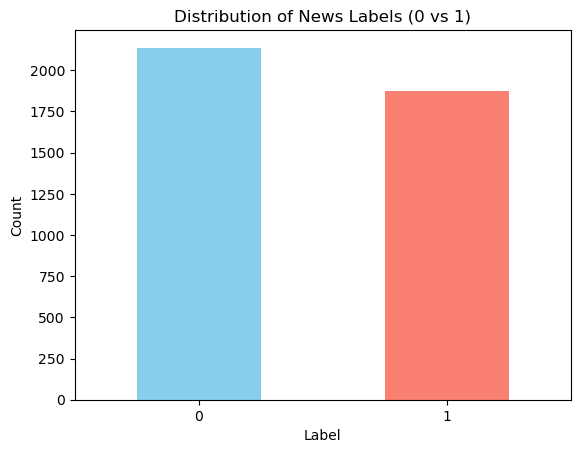

In [14]:
df["Label"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Distribution of News Labels (0 vs 1)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [15]:
joblib.dump(model, "fake_news_model.pkl")

['fake_news_model.pkl']